## Astronomy 3350
### The basics of MCMC modeling
### Wednesday, December 3

This notebook illustrates the operation of the `pymc` package to model
a simple distribution, namely to find the mean and standard deviation 
of a set of data.

__Begin__ by importing packages.

In [4]:
# Numerical python
import numpy as np

# Plotting and statistical visualization library
import matplotlib.pyplot as plt
import seaborn as sns

# Construction and visualization of MCMC chains
import pymc as pm
import arviz as az

ModuleNotFoundError: No module named 'seaborn'

__Set plot style:__ We do this with a dictionary update method.

In [2]:
# Small dictionary with our selected changes.
style_revisions = { 
    'font.size' : 11,
    'figure.figsize' : [7.5, 5.5],
    'axes.linewidth': 1.5,
    'lines.linewidth' : 2.5,
    'xtick.top' : True,
    'ytick.right' : True, 
    'xtick.direction' : 'in',
    'ytick.direction' : 'in', 
    'xtick.major.size' : 11,
    'ytick.major.size' : 11, 
    'xtick.minor.size' : 5.5,
    'ytick.minor.size' : 5.5
}
# Update the matplotlib dictionary.
plt.rcParams.update(style_revisions)

### Generate data

We define a function that produces normally distributed values
around a mean, with a baseline noise level added to Poisson-like
(root-value) errors.

This illustrates how you can set up default values ('factory 
settings') for numbers in a function, which can be overridden
with function arguments.

In [3]:
# Data generating function
def gen_d(mean=10, sigbase=10, npts=25):
    """
    Returns Poisson-like distribution with an added base noise
    Optional arguments:
        mean        Average data value     [default 10]
        sigbase     Added noise            [default 15]
        npts        Number of data values  [default 25]

    """
    # Data values before noise
    dp = [ mean for k in range(npts) ]
    # Noise on each point
    er = [ (v + sigbase)**0.5 for v in dp ]
    # Add random noise on each point
    ev = [ np.random.normal(0.0, v, 1)[0] for v in er ]
    dv = [ v + e for v, e in zip(dp, ev) ]
    # Return the data values
    return dv

Now generate the data.  It will be a python list.

In [4]:
ydata = gen_d()   

### Basic statistics.

These are _point estimates_ for the mean and standard deviation.  Later we will
see how MCMC codes return _probabilistic_ estimates for these model parameters.
We can use the basic statistics to set priors for the MCMC modeling.

In [5]:
# Ordinary stats and resisuals
o_mean = np.average(ydata)
o_sigma = np.std(ydata)
print('Mean = %.2f std. dev = %.2f' % (o_mean, o_sigma))

Mean = 9.54 std. dev = 5.16


### Show the data values and model parameters

We call these model parameters because we will later construct a model
where the data are considered to be distributed about some mean value
$\mu$ with a standard deviation $\sigma$.

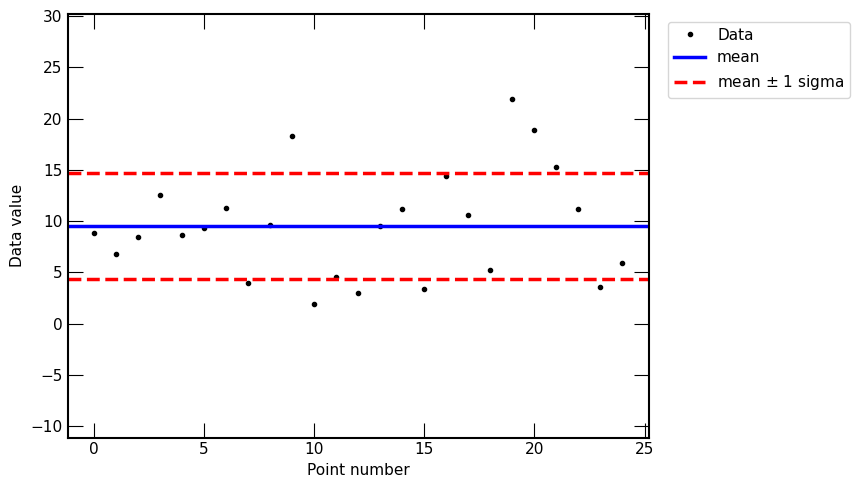

In [6]:
# mean plus or minus 1 sigma
mean_psig = o_mean + o_sigma
mean_msig = o_mean - o_sigma

# Plot data values
fig, ax = plt.subplots()
ax.plot(ydata, '.k', label='Data')

# Model parameters
llabel = r'mean $\pm$ 1 sigma'
ax.axhline(o_mean, c='blue', label='mean')
ax.axhline(mean_msig, c='red', linestyle='--')
ax.axhline(mean_psig, c='red', linestyle='--', label=llabel)

# Limits
ax.set_ylim(o_mean - 4 * o_sigma, o_mean + 4 * o_sigma)

# Labels and legends
ax.set_xlabel('Point number')
ax.set_ylabel('Data value')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

### Examine the distribution of data values to justify an error model

We compare the cumulative distribution of data values to a normal
distribution with the same mean and standard deviation.  There are
nice visualization tools within `seaborn` for just this sort of thing.

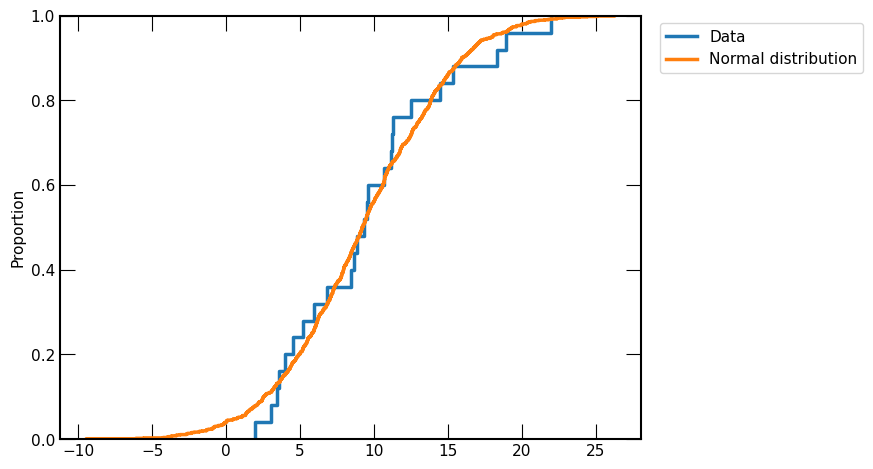

In [7]:
# A normal distribution with the same estimators as the data.
# A large number of points will make a smooth cumulative distribution.
ygmodel = np.random.normal(o_mean, o_sigma, 1024)

# Show the cumulative distributions for the model and the data
sns.ecdfplot(ydata, label='Data')
sns.ecdfplot(ygmodel, label='Normal distribution')
plt.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left')
plt.show()

__Analysis:__ There are numerical tests which can show how close a data distribution
is to a normal distribution, but here we can say 'looks OK to me' and proceed with
modeling the data as having a mean and a normal distribution about that mean:

$$
y \sim N(\mu, \sigma)
$$

Here the model parameters are the mean and the standard deviation.

The model is constructed in `pymc` by 
- naming the variables and establishing a prior distribution for each,
- specifying the model, in this case a simple mean,
- specifying how the data values are distributed around the mean, in this case normally, and
- letting the model produce a _sampling chain_ to derive values for model parameters that are distributed like the posterior probability for each.

These are all bound to the model object through the powerful python operator `with`.  It is worth reading about how this works.

We can use our simple statistical estimators to set the priors:
- Prior on $\mu$ is normal, centered on the data mean, with standard deviation twice as wide as the data standard deviation.
- Prior on $\sigma$ is half normal with width twice the data standard devation.  A half normal distribution looks like the top half of a Gaussian with maximum value at zero.  We do this since the value of $\sigma$ cannot be negative.

In [8]:
with pm.Model() as basic_model:
    # Wide priors using simple stats as central values
    mu = pm.Normal('mu', mu=o_mean, sigma=2*o_sigma)
    sigma = pm.HalfNormal('sigma', sigma=2*o_sigma)
    
    # Model is simple
    y = mu
    
    # Outcomes - we can use the default number of chains and length of chains
    y_obs = pm.Normal('y_obs', y, sigma, observed=ydata)
    chains = pm.sample()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


### Show a summary table of the distribution of model parameters.

In [9]:
az.summary(chains, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,9.58,1.11,7.41,11.63,0.02,0.01,3627.71,2619.90,1.0
sigma,5.52,0.86,4.04,7.20,0.02,0.01,3255.40,2794.59,1.0


### Plot the distribution of the model pameters, showing each chain.

Each chain _samples_ the posterior distribution, so we should not expect that
the result is identical for each chain.

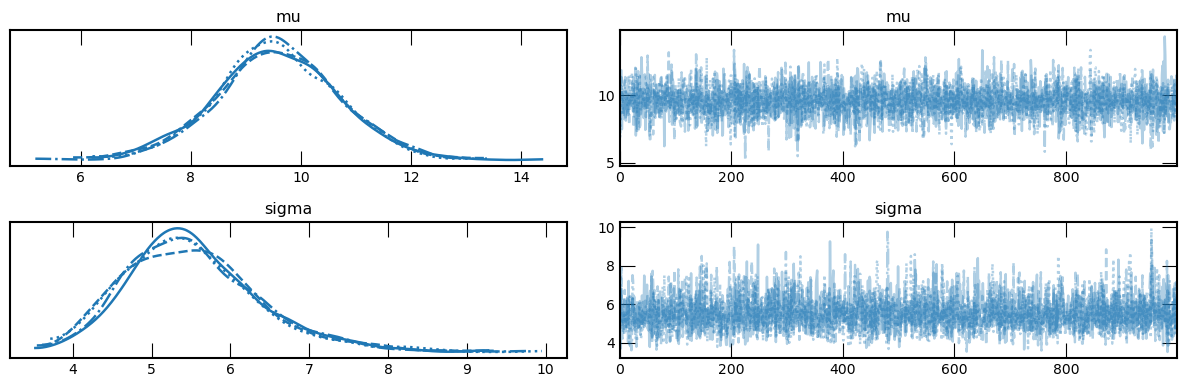

In [10]:
az.plot_trace(chains)
plt.tight_layout()

### Do the same plot with all chains combined.

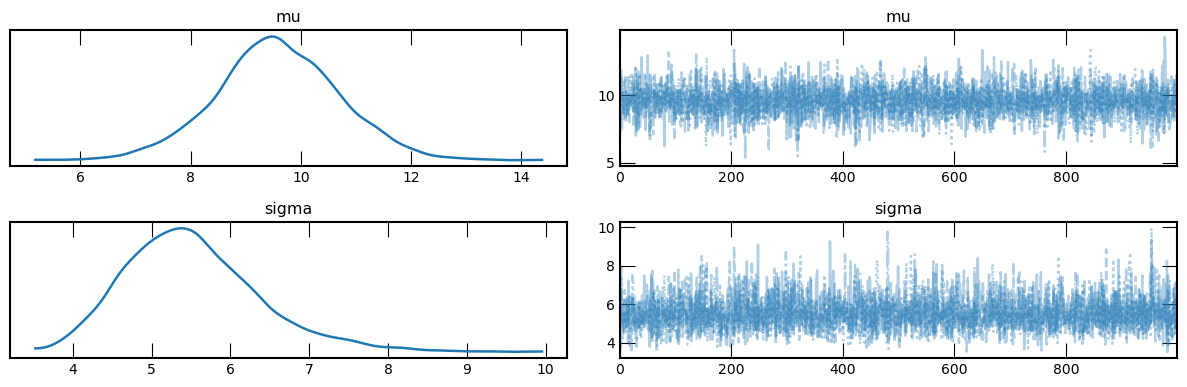

In [11]:
az.plot_trace(chains, combined=True)
plt.tight_layout()

### Display the characteristics of the posterior data arrays and manually combine them.

In [12]:
# Combine the chains for the mu parameter and show the data shape.
mean_values_per_chain = chains.posterior["mu"]
print(f"Shape of 'mean' values per chain: {mean_values_per_chain.shape}")
mean_combined = chains.posterior.stack(sample=["chain", "draw"])["mu"]
print(f"Shape of combined 'mean' values: {mean_combined.shape}")

# Combine the posterior sample values for the sigma. In this case, the
# data arrays have the same shape as for the mean
sigma_values_per_chain = chains.posterior["sigma"]
sigma_combined = chains.posterior.stack(sample=["chain", "draw"])["sigma"]

Shape of 'mean' values per chain: (4, 1000)
Shape of combined 'mean' values: (4000,)


### Display the individual values in the combined chain

We also show the point estimate to note that the posterior distributions
are not necessarily symmetric around these point estimates

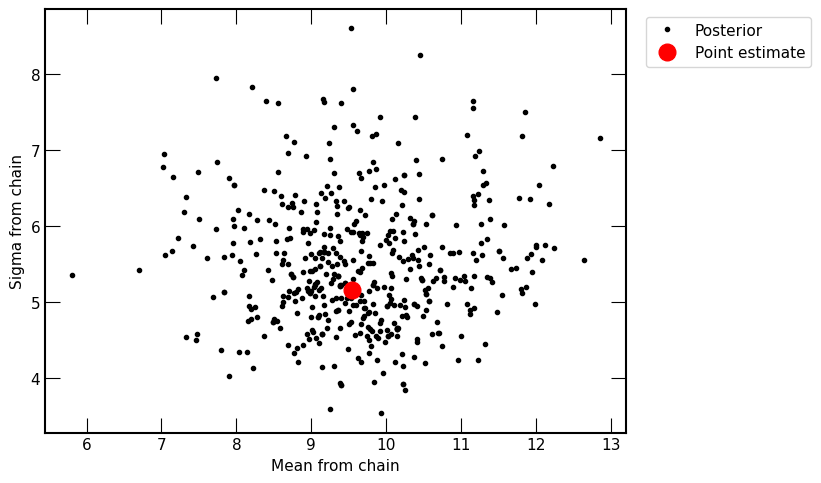

In [13]:
# Plot last N from the combined chain
nlast = 500
fig, ax = plt.subplots()
ax.plot(mean_combined[-nlast: ], sigma_combined[-nlast: ], '.k', label='Posterior')
ax.plot(o_mean, o_sigma, 'or', markersize=12, label='Point estimate')
ax.set_xlabel('Mean from chain')
ax.set_ylabel('Sigma from chain')
ax.legend(bbox_to_anchor=(1.02, 1.00), loc='upper left')
plt.show()

### Display a 'heat map' in hexplot form of the posterior distributions

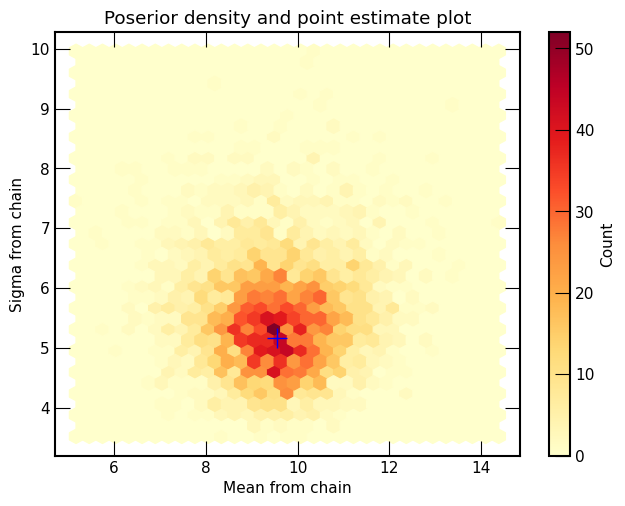

In [14]:
gridsize = 32
fig, ax = plt.subplots()
C = ax.hexbin(mean_combined, sigma_combined, 
           gridsize=gridsize, cmap='YlOrRd') 
plt.colorbar(C, label='Count')
ax.set_title('Poserior density and point estimate plot')
ax.set_xlabel('Mean from chain')
ax.set_ylabel('Sigma from chain')
ax.plot(o_mean, o_sigma, '+b', markersize=15)
plt.show()